# フェーズ6：実データ取込・EDA

`test_data/` に提供された実データ（TSV）を集計し、傾向とデータ品質を確認する。

- **A系統（主軸）**：CSPM 購買 → `data/real_store_daily.csv`（店舗×日）
- **B系統（独立デモ）**：通行人カウント → `data/real_flow_daily.csv`（端末×日）

> 前提：来店（通行人）と購買は店舗単位でリンクできない（端末→店舗マッピング未提供）ため、両者を別々に扱う。
> 天候は当面なし（実物CSV未提供）。カレンダー＋ラグ特徴で予測する方針。

集計は `src/real_data_etl.py` で実施済み（本ノートブックはその出力を読み込む）。未実行の場合は先に `python src/real_data_etl.py` を実行。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

store = pd.read_csv("data/real_store_daily.csv", dtype={"shop_id": str}, parse_dates=["date"])
flow = pd.read_csv("data/real_flow_daily.csv", dtype={"device_id": str}, parse_dates=["date"])

print("[A] store_daily:", store.shape, "| 店舗数:", store["shop_id"].nunique(),
      "|", store["date"].min().date(), "〜", store["date"].max().date())
print("[B] flow_daily :", flow.shape, "| 端末:", flow["device_id"].unique().tolist(),
      "|", flow["date"].min().date(), "〜", flow["date"].max().date())
store.head()

Matplotlib is building the font cache; this may take a moment.


[A] store_daily: (9944, 10) | 店舗数: 187 | 2024-10-01 〜 2026-06-15
[B] flow_daily : (162, 4) | 端末: ['1000000', 'UNKNOWN'] | 2025-11-19 〜 2026-06-12


,shop_id,date,receipts,members,gross_sales,discount,returns,return_amount,net_sales,avg_spend
0,005497,2024-10-01,83,69,639656,4081,1.0,3522.0,636134.0,7664.3
1,005497,2024-10-02,87,80,643745,18112,0.0,-0.0,643745.0,7399.4
2,005497,2024-10-03,67,61,415665,5477,1.0,1991.0,413674.0,6174.2
3,005497,2024-10-04,78,64,490114,9459,1.0,35334.0,454780.0,5830.5
4,005497,2024-10-05,78,64,356441,472,1.0,435.0,356006.0,4564.2


## 1. データ品質：店舗ごとの日次カバレッジ

日次予測ができるかは「各店舗にどれだけ連続した日次データがあるか」に依存する。
実データは全店・全期間そろっているわけではないため、まずカバレッジを確認する。

In [2]:
cov = store.groupby("shop_id")["date"].agg(["min", "max", "nunique"])
cov["span_days"] = (cov["max"] - cov["min"]).dt.days + 1
cov["coverage"] = (cov["nunique"] / cov["span_days"]).round(2)

print("=== 店舗ごとの実日数(nunique)の分布 ===")
print(cov["nunique"].describe().round(1))
print("\n=== 日次カバレッジ(実日数/期間)の分布 ===")
print(cov["coverage"].describe().round(2))

# 密にそろっている店舗（連続日次が十分ある店舗）を抽出
DENSE_MIN_DAYS = 60
dense = cov[cov["nunique"] >= DENSE_MIN_DAYS].sort_values("nunique", ascending=False)
print(f"\n連続日次が {DENSE_MIN_DAYS} 日以上ある店舗数: {len(dense)} / {len(cov)}")
dense.head(10)

=== 店舗ごとの実日数(nunique)の分布 ===
count    187.0
mean      53.2
std       34.7
min        3.0
25%       22.0
50%       24.0
75%       91.0
max       91.0
Name: nunique, dtype: float64

=== 日次カバレッジ(実日数/期間)の分布 ===
count    187.00
mean       0.50
std        0.46
min        0.01
25%        0.06
50%        0.08
75%        1.00
max        1.00
Name: coverage, dtype: float64

連続日次が 60 日以上ある店舗数: 86 / 187


,min,max,nunique,span_days,coverage
shop_id,,,,,
005497,2024-10-01,2024-12-30,91,91,1.0
005882,2024-10-01,2024-12-30,91,91,1.0
005918,2024-10-01,2024-12-30,91,91,1.0
005915,2024-10-01,2024-12-30,91,91,1.0
005909,2024-10-01,2024-12-30,91,91,1.0
005906,2024-10-01,2024-12-30,91,91,1.0
005900,2024-10-01,2024-12-30,91,91,1.0
005894,2024-10-01,2024-12-30,91,91,1.0
005888,2024-10-01,2024-12-30,91,91,1.0


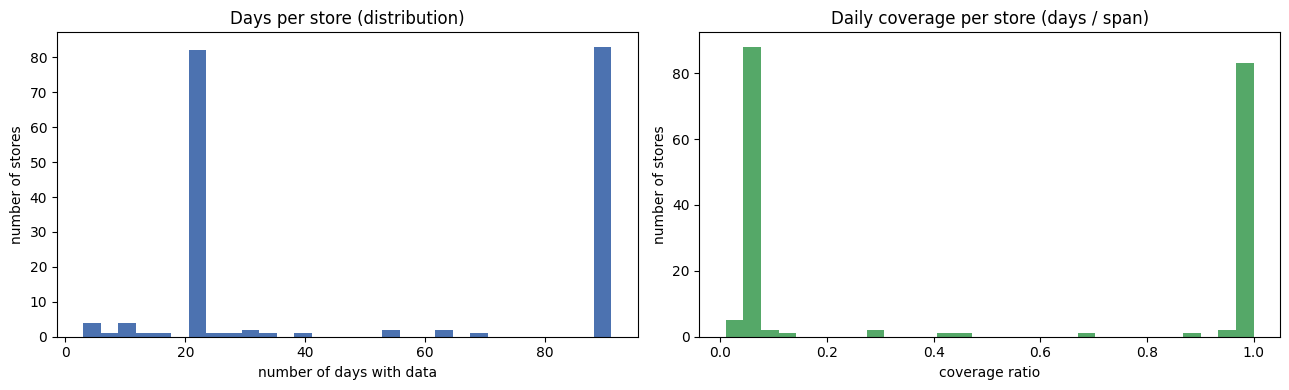

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cov["nunique"], bins=30, color="#4C72B0")
axes[0].set_title("Days per store (distribution)")
axes[0].set_xlabel("number of days with data")
axes[0].set_ylabel("number of stores")

axes[1].hist(cov["coverage"], bins=30, color="#55A868")
axes[1].set_title("Daily coverage per store (days / span)")
axes[1].set_xlabel("coverage ratio")
axes[1].set_ylabel("number of stores")
plt.tight_layout()
plt.show()

## 2. 主要指標の時系列（密な店舗）

連続日次のある店舗について、購買客数（receipts）・純売上（net_sales）・客単価（avg_spend）の推移を見る。
これが A系統（購買来店・売上）の予測対象。

表示対象店舗: ['005497', '005882', '005918']


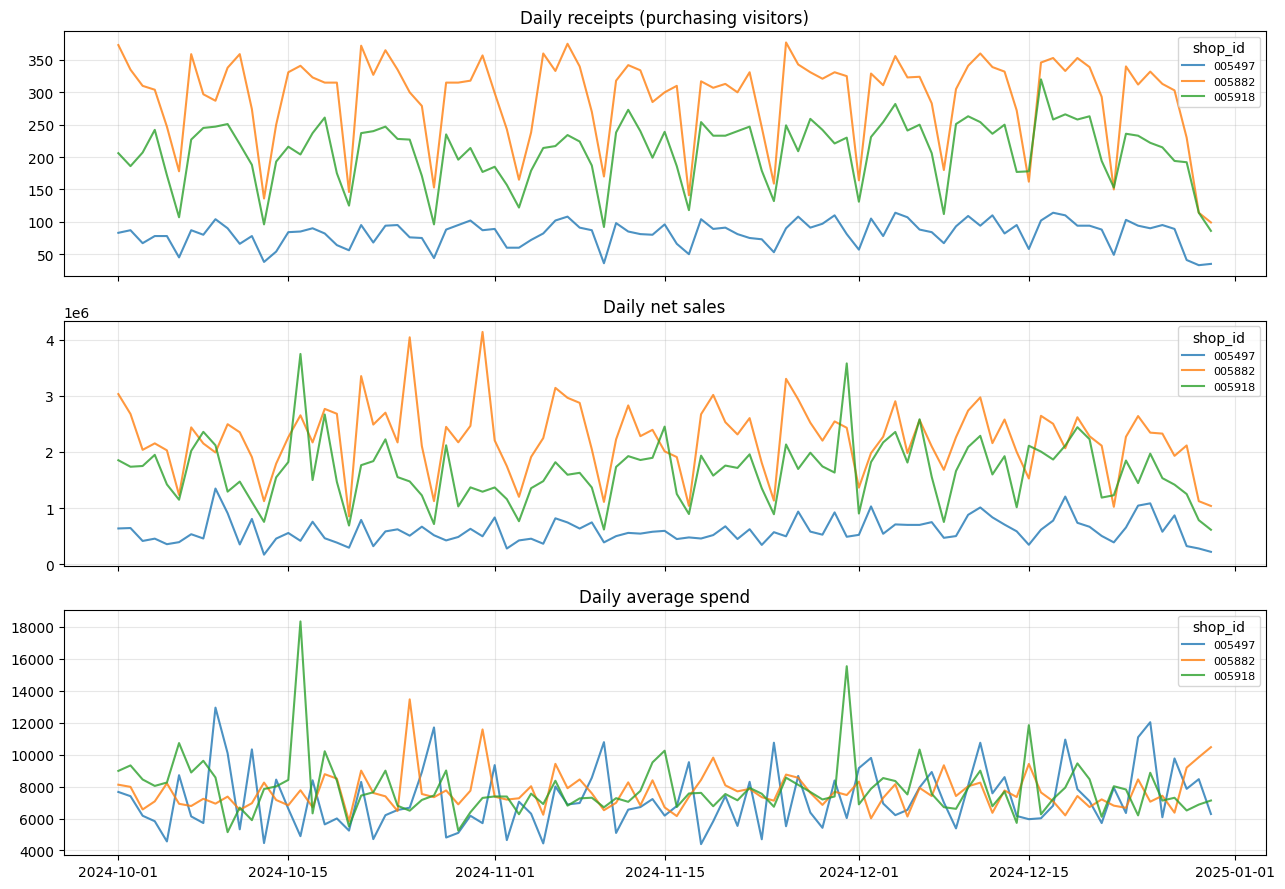

In [4]:
sample_shops = dense.index[:3].tolist()
print("表示対象店舗:", sample_shops)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for shop_id in sample_shops:
    d = store[store["shop_id"] == shop_id].sort_values("date")
    axes[0].plot(d["date"], d["receipts"], label=shop_id, alpha=0.8)
    axes[1].plot(d["date"], d["net_sales"], label=shop_id, alpha=0.8)
    axes[2].plot(d["date"], d["avg_spend"], label=shop_id, alpha=0.8)

axes[0].set_title("Daily receipts (purchasing visitors)")
axes[1].set_title("Daily net sales")
axes[2].set_title("Daily average spend")
for ax in axes:
    ax.legend(title="shop_id", fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 曜日・祝日効果（カレンダー特徴の効き）

購買来店（receipts）に曜日・祝日の周期があるかを確認する。効いていれば、
カレンダー特徴だけでもベースラインを超える余地がある（＝天候が無くても予測の型は成立する）。

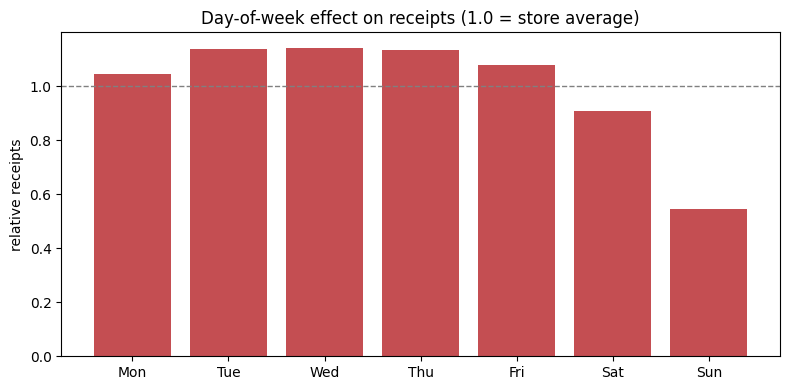

平日 vs 休日(祝日)の平均 receipts_norm:
is_holiday
False    1.009
True     0.801
Name: receipts_norm, dtype: float64


In [5]:
try:
    import jpholiday
    def is_holiday(d):
        return jpholiday.is_holiday(d)
except Exception:
    def is_holiday(d):
        return False

dense_store = store[store["shop_id"].isin(dense.index)].copy()
dense_store["dow"] = dense_store["date"].dt.dayofweek  # 0=Mon
dense_store["is_holiday"] = dense_store["date"].dt.date.map(is_holiday)

# 各店舗の平均で正規化してから曜日平均（店舗規模差を除く）
dense_store["receipts_norm"] = dense_store.groupby("shop_id")["receipts"].transform(
    lambda s: s / s.mean()
)
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_effect = dense_store.groupby("dow")["receipts_norm"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([dow_labels[i] for i in dow_effect.index], dow_effect.values, color="#C44E52")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_title("Day-of-week effect on receipts (1.0 = store average)")
ax.set_ylabel("relative receipts")
plt.tight_layout()
plt.show()

print("平日 vs 休日(祝日)の平均 receipts_norm:")
print(dense_store.groupby("is_holiday")["receipts_norm"].mean().round(3))

## 4. 来店（receipts）と売上（net_sales）の関係

「売上 ＝ 来店客数 × 客単価」の分解が実データでも妥当かを確認する。
相関が強ければ、来店予測 → 客単価 → 売上 の接続が有効。

receipts と net_sales の相関: 0.909
members と receipts の相関: 0.995


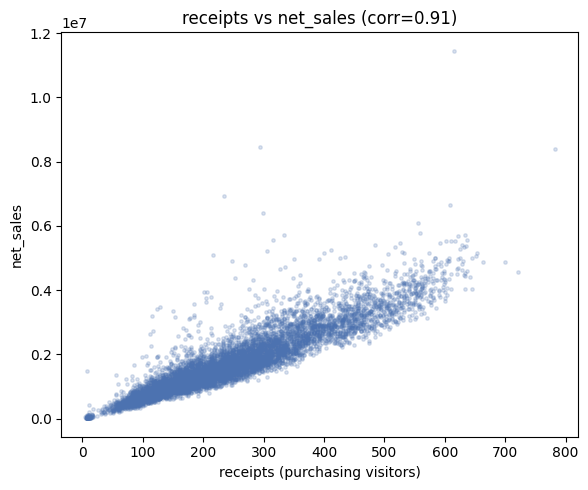

In [6]:
valid = dense_store[(dense_store["receipts"] > 0) & (dense_store["net_sales"] > 0)]
corr = valid["receipts"].corr(valid["net_sales"])
print(f"receipts と net_sales の相関: {corr:.3f}")
print(f"members と receipts の相関: {valid['members'].corr(valid['receipts']):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid["receipts"], valid["net_sales"], s=6, alpha=0.2, color="#4C72B0")
ax.set_xlabel("receipts (purchasing visitors)")
ax.set_ylabel("net_sales")
ax.set_title(f"receipts vs net_sales (corr={corr:.2f})")
plt.tight_layout()
plt.show()

## 5. B系統：通行人カウント（単店）の日次入店数

端末1台（`1000000`）の日次入店数（IN集計）。購買とはリンクできないため独立に扱う。
`UNKNOWN` 端末は分けて確認する。

端末別の日数・IN合計:
           days  in_sum  out_sum
device_id                       
1000000     145   25176    22200
UNKNOWN      17    2924     3081


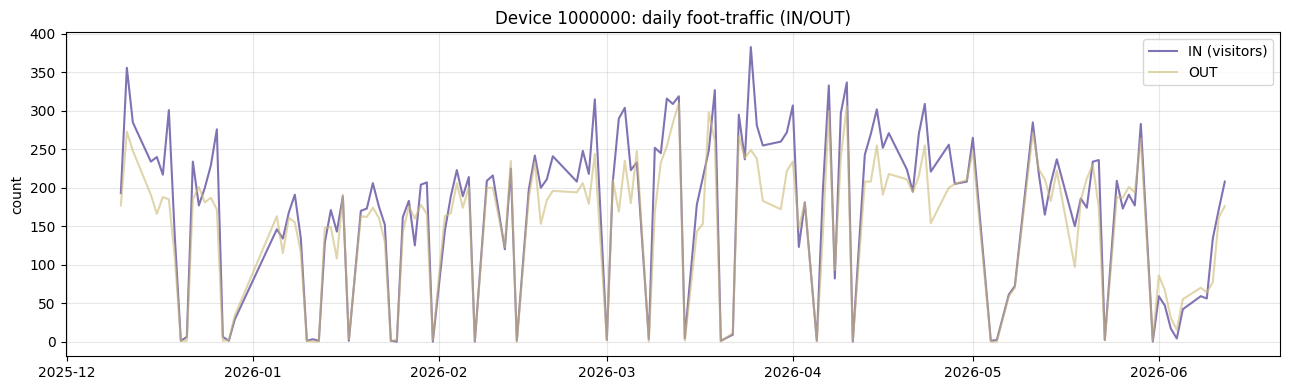


IN 平均/日: 173.6 / 日数: 145
期間: 2025-12-10 〜 2026-06-12（185日）→ 欠損日あり


In [7]:
main_dev = flow[flow["device_id"] == "1000000"].sort_values("date")
print("端末別の日数・IN合計:")
print(flow.groupby("device_id").agg(days=("date", "nunique"),
                                    in_sum=("visitors_in", "sum"),
                                    out_sum=("events_out", "sum")))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(main_dev["date"], main_dev["visitors_in"], color="#8172B3", label="IN (visitors)")
ax.plot(main_dev["date"], main_dev["events_out"], color="#CCB974", alpha=0.6, label="OUT")
ax.set_title("Device 1000000: daily foot-traffic (IN/OUT)")
ax.set_ylabel("count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nIN 平均/日: {main_dev['visitors_in'].mean():.1f} / 日数: {main_dev['date'].nunique()}")
print(f"期間: {main_dev['date'].min().date()} 〜 {main_dev['date'].max().date()}"
      f"（{(main_dev['date'].max()-main_dev['date'].min()).days+1}日）→ 欠損日あり")

## 6. まとめと次のステップ

### わかったこと
- **購買（A系統）**：187店・2024-10〜2026-06。ただし**日次カバレッジに強い偏り**があり、連続日次がそろうのは一部店舗（主に2024Q4の約3か月ブロック）。
- **来店（receipts）は曜日・祝日の周期を持つ**見込み → カレンダー特徴だけでもベースライン超えの余地。
- **receipts と net_sales は強い相関** → 「来店 × 客単価 → 売上」の分解が実データでも有効。
- **通行人（B系統）**：単店・約180人/日・欠損日あり。購買とはリンク不可。

### データ品質の注意点
- 返品(RETN)は購入額が**負値**（ETLで純売上に反映済み）。
- 多くの店舗は連続日次が不足 → 日次モデルは**カバレッジの高い店舗に限定**するか、**複数店舗プール（店舗IDを特徴に）**で学習する。
- 天候・SNS・外部人流は当面なし（要件定義の方針どおり）。

### 次のステップ（フェーズ6.5：A系統の予測）
1. カバレッジの高い店舗集合を確定（例：連続60日以上）。
2. 特徴量：曜日・祝日・月・給料日・月初/月末＋ receipts/net_sales の**ラグ・移動平均**（リーク対策）。
3. `src/visit_forecast.py` の型を流用し、**時系列分割**で receipts を予測 → ベースライン（曜日平均・前年/前週同曜日）と比較。
4. 客単価モデルを掛けて net_sales を推定、直接予測とも比較。
5. 結果を `src/llm_advisor.py` で解釈・施策提案（既存フェーズ5の流用）。